# Macro-activités des entreprises — Bâtiment et travaux publics


## Objectif et principe

Le fichier source contient deux systèmes de codification : les codes antérieurs
à 2015 sont des **codes risque historiques** et les codes plus récents des
**codes APE/NAF**. Ils ne sont donc pas ramenés artificiellement à une division
NAF commune.

Chaque accident reçoit trois variables de traçabilité : `company_code`,
`company_label` et `coding_system`. La variable `macro_activity` est construite
à partir du **libellé d'activité**, au moyen de règles explicites et ordonnées.
Elle définit des contextes BTP homogènes pour l'analyse locale des motifs.

Les familles comptant au moins `MIN_CANDIDATE_SIZE` accidents sont exportées
comme candidates à l'analyse locale. Les autres restent visibles dans
`macro_activity_raw`, mais leur famille finale est `Other activities`. Chaque
ligne exportée conserve `accident_id`, ce qui maintient le lien avec les unités
factuelles et les embeddings.


In [1]:
from pathlib import Path
import re

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

DATASET = "btp"
DATA_PATH = Path("data/btp_sentence_accidents.csv")
EXPORT_PATH = Path("../dataset/company_family_btp.csv")
MIN_CANDIDATE_SIZE = 75
TAXONOMY_VERSION = "label_based_btp_macro_activity_v1"


In [2]:
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Fichier introuvable : {DATA_PATH.resolve()}")

sentences = pd.read_csv(DATA_PATH, dtype={"accident_id": "string", "company_code": "string"})
required_columns = {"accident_id", "company_code"}
missing_columns = required_columns.difference(sentences.columns)
if missing_columns:
    raise ValueError(f"Colonnes absentes : {sorted(missing_columns)}")

company_values = sentences.assign(company_code=sentences["company_code"].astype("string").str.strip())
company_values["company_code"] = company_values["company_code"].replace("", pd.NA)
conflicts = company_values.groupby("accident_id", dropna=False)["company_code"].nunique(dropna=True)
if conflicts.gt(1).any():
    raise ValueError("Au moins un accident poss?de plusieurs codes entreprise distincts.")

accidents = (
    company_values.groupby("accident_id", as_index=False, dropna=False)["company_code"]
    .agg(lambda values: values.dropna().iloc[0] if not values.dropna().empty else pd.NA)
    .rename(columns={"company_code": "company_code_raw"})
)
print(f"{DATASET}: {len(accidents):,} accidents uniques")


btp: 6,040 accidents uniques


In [3]:
TAXONOMY_RULES = (
    ("building_construction_and_masonry", "Building construction and masonry", r"gros.{0,6}uvre|ma.onnerie|construction d.autres b.timents|maisons individuelles"),
    ("roofing_and_waterproofing", "Roofing and waterproofing", r"couverture|.tanch"),
    ("civil_engineering_and_networks", "Civil engineering and networks", r"ouvrages d.art|chauss|sols sportifs|pavage|lignes .lectriques|t.l.communication|travaux urbains|canalisations . grande distance|voies ferr|maritimes|fluviaux|r.seaux (?:.lectriques|pour fluides)|routes et autoroutes|tunnels"),
    ("earthworks_foundations_and_demolition", "Earthworks, foundations and demolition", r"terrass|forages|fondations|d.molition|sondages"),
    ("electrical_installation", "Electrical installation", r"installation .lectrique|pose d.enseignes|paratonnerres|antennes"),
    ("plumbing_heating_and_hvac", "Plumbing, heating and HVAC", r"plomberie|sanitaires|installation d.eau et de gaz|.quipements thermiques|climatisation|a.raulique|frigorifique"),
    ("carpentry_and_joinery", "Carpentry and joinery", r"menuiserie|charpente"),
    ("building_finishing_and_insulation", "Building finishing and insulation", r"peinture|ravalement|am.nagement int.rieur|isolation|pl.trerie|rev.tement|finitions|ass.chement|ignifugation"),
    ("metal_construction_and_assembly", "Metal construction and assembly", r"construction m.tallique|structures m.talliques|m.tallerie|serrurerie"),
    ("construction_equipment_with_operator", "Construction equipment with operator", r"location de mat.riel.*b.timent|location avec op.rateur"),
    ("engineering_and_project_support", "Engineering and project support", r"ing.nierie|architecture|topographie|m.tr.s"),
)


parsed = accidents["company_code_raw"].astype("string").str.extract(
    r"^\s*(?P<company_code>(?:\d{4}[A-Z]|\d{3}[A-Z]{2}))\s*-\s*(?P<company_label>.+?)\s*$"
)
accidents["company_code"] = parsed["company_code"].astype("string")
accidents["company_label"] = parsed["company_label"].astype("string")

# The format identifies the source system; historical codes are never read as NAF.
accidents["coding_system"] = pd.Series("unclassified", index=accidents.index, dtype="string")
accidents.loc[accidents["company_code"].str.fullmatch(r"\d{3}[A-Z]{2}").fillna(False), "coding_system"] = "historical_risk_code"
accidents.loc[accidents["company_code"].str.fullmatch(r"\d{4}[A-Z]").fillna(False), "coding_system"] = "NAF_APE"


def assign_macro_activity(label: object) -> tuple[str, str]:
    if pd.isna(label):
        return "Other activities", "missing_or_unparseable_label"
    label_text = str(label).lower()
    for rule_id, macro_activity, pattern in TAXONOMY_RULES:
        if re.search(pattern, label_text):
            return macro_activity, rule_id
    return "Other activities", "no_taxonomy_rule_matched"


assignments = accidents["company_label"].map(assign_macro_activity)
accidents[["macro_activity_raw", "macro_activity_rule"]] = pd.DataFrame(
    assignments.tolist(), index=accidents.index
)
accidents["macro_activity_raw"] = accidents["macro_activity_raw"].astype("string")
accidents["macro_activity_rule"] = accidents["macro_activity_rule"].astype("string")

raw_counts = accidents["macro_activity_raw"].value_counts()
accidents["macro_activity_size_before_other"] = accidents["macro_activity_raw"].map(raw_counts).astype("Int64")
accidents["macro_activity"] = accidents["macro_activity_raw"].copy()
small_or_other = (
    accidents["macro_activity_raw"].eq("Other activities")
    | accidents["macro_activity_size_before_other"].lt(MIN_CANDIDATE_SIZE)
)
accidents.loc[small_or_other, "macro_activity"] = "Other activities"
accidents["is_local_analysis_candidate"] = ~accidents["macro_activity"].eq("Other activities")
accidents["family"] = accidents["macro_activity"]
accidents["family_grouping_reason"] = pd.Series(
    "Rule applied to company_label: " + accidents["macro_activity_rule"],
    index=accidents.index,
    dtype="string",
)
accidents.loc[small_or_other, "family_grouping_reason"] = (
    "Other activities: raw macro-activity is unmatched or below "
    + str(MIN_CANDIDATE_SIZE)
    + " accidents; raw assignment retained in macro_activity_raw."
)
accidents["taxonomy_version"] = TAXONOMY_VERSION


In [4]:
def distribution(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    table = frame[column].fillna("Not recorded").value_counts(dropna=False).rename_axis(column).reset_index(name="n_accidents")
    table["part_pct"] = (100 * table["n_accidents"] / len(frame)).round(1)
    return table

summary = pd.DataFrame([{
    "dataset": DATASET,
    "n_accidents": len(accidents),
    "n_historical_risk_code": int(accidents["coding_system"].eq("historical_risk_code").sum()),
    "n_NAF_APE": int(accidents["coding_system"].eq("NAF_APE").sum()),
    "n_local_analysis_candidates": int(accidents["is_local_analysis_candidate"].sum()),
    "n_candidate_macro_activities": int(accidents.loc[accidents["is_local_analysis_candidate"], "macro_activity"].nunique()),
    "minimum_candidate_size": MIN_CANDIDATE_SIZE,
}])
macro_distribution = distribution(accidents, "macro_activity")
raw_macro_distribution = distribution(accidents, "macro_activity_raw")
coding_system_distribution = distribution(accidents, "coding_system")
rule_audit = (
    accidents.groupby(["macro_activity_rule", "macro_activity_raw"], dropna=False)
    .agg(n_accidents=("accident_id", "size"), n_company_codes=("company_code", "nunique"))
    .reset_index()
    .sort_values("n_accidents", ascending=False, kind="stable")
)

print("Summary")
display(summary)
print("Macro-activity distribution")
display(macro_distribution)
print("Mapping-rule audit")
display(rule_audit)


Summary


,dataset,n_accidents,n_historical_risk_code,n_NAF_APE,n_local_analysis_candidates,n_candidate_macro_activities,minimum_candidate_size
0,btp,6040,5048,992,5869,11,75


Macro-activity distribution


,macro_activity,n_accidents,part_pct
0,Building construction and masonry,2382,39.4
1,Civil engineering and networks,1041,17.2
2,Building finishing and insulation,708,11.7
3,Carpentry and joinery,417,6.9
4,Electrical installation,323,5.3
5,"Earthworks, foundations and demolition",279,4.6
6,Roofing and waterproofing,253,4.2
7,Other activities,171,2.8
8,"Plumbing, heating and HVAC",171,2.8
9,Metal construction and assembly,144,2.4


Mapping-rule audit


,macro_activity_rule,macro_activity_raw,n_accidents,n_company_codes
0,building_construction_and_masonry,Building construction and masonry,2382,5
3,civil_engineering_and_networks,Civil engineering and networks,1041,13
1,building_finishing_and_insulation,Building finishing and insulation,708,8
2,carpentry_and_joinery,Carpentry and joinery,417,5
6,electrical_installation,Electrical installation,323,5
5,earthworks_foundations_and_demolition,"Earthworks, foundations and demolition",279,5
11,roofing_and_waterproofing,Roofing and waterproofing,253,3
9,no_taxonomy_rule_matched,Other activities,171,46
10,plumbing_heating_and_hvac,"Plumbing, heating and HVAC",171,5
8,metal_construction_and_assembly,Metal construction and assembly,144,4


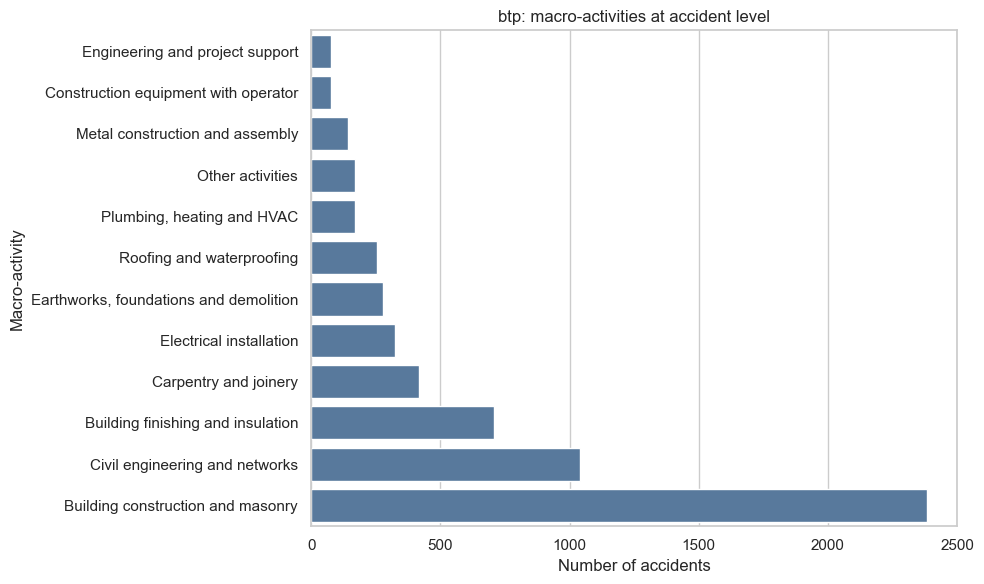

In [5]:
sns.set_theme(style="whitegrid")
plot_data = macro_distribution.sort_values("n_accidents", ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_data, y="macro_activity", x="n_accidents", color="#4C78A8", ax=ax)
ax.set_title(f"{DATASET}: macro-activities at accident level")
ax.set_xlabel("Number of accidents")
ax.set_ylabel("Macro-activity")
plt.tight_layout()
plt.show()


## Audit de la taxonomie

Les r?gles de la cellule de classification sont volontairement visibles et appliqu?es dans l'ordre indiqu?. Le tableau `rule_audit` donne leur effectif. Les lignes sans r?gle, ainsi que les familles sous le seuil, restent dans `Other activities`; leur affectation initiale demeure disponible dans `macro_activity_raw` pour contr?le expert et r?vision de la taxonomie.


In [6]:
export_columns = [
    "accident_id",
    "company_code_raw",
    "company_code",
    "company_label",
    "coding_system",
    "macro_activity_raw",
    "macro_activity_rule",
    "macro_activity_size_before_other",
    "macro_activity",
    "is_local_analysis_candidate",
    "family",
    "family_grouping_reason",
    "taxonomy_version",
]
family_export = accidents[export_columns].sort_values("accident_id", kind="stable")
if not family_export["accident_id"].is_unique:
    raise AssertionError("The export must contain one row per accident_id.")
EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
family_export.to_csv(EXPORT_PATH, index=False)
print(f"Export written: {EXPORT_PATH.resolve()}")
display(family_export.head())

# Example join:
# dataset = pd.read_csv(Path(f"../dataset/data_{DATASET}.csv"), dtype={"accident_id": "string"})
# dataset_with_family = dataset.merge(family_export[["accident_id", "family"]], on="accident_id", how="left")


Export written: C:\Users\aho\Documents\analysis factor project\SAFER\text\dataset\company_family_btp.csv


,accident_id,company_code_raw,company_code,company_label,coding_system,macro_activity_raw,macro_activity_rule,macro_activity_size_before_other,macro_activity,is_local_analysis_candidate,family,family_grouping_reason,taxonomy_version
0,0003B264171D6748C125719D00535F82,"452JD - Couverture, travaux de maçonnerie en bois, travaux d'étanchéité",452JD,"Couverture, travaux de maçonnerie en bois, travaux d'étanchéité",historical_risk_code,Building construction and masonry,building_construction_and_masonry,2382,Building construction and masonry,True,Building construction and masonry,Rule applied to company_label: building_construction_and_masonry,label_based_btp_macro_activity_v1
1,002257F8911857E6C125719D0055EA96,"453AE - Travaux d'installation électrique, pose d'enseignes et de stores, fermetures (fabrication et pose de jalousies, volets, persiennes, etc.)",453AE,"Travaux d'installation électrique, pose d'enseignes et de stores, fermetures (fabrication et pose de jalousies, volets, persiennes, etc.)",historical_risk_code,Electrical installation,electrical_installation,323,Electrical installation,True,Electrical installation,Rule applied to company_label: electrical_installation,label_based_btp_macro_activity_v1
2,002DD5AD79D498BCC125719D0056155C,452BD - Travaux de gros oeuvre et organisation de chantiers,452BD,Travaux de gros oeuvre et organisation de chantiers,historical_risk_code,Building construction and masonry,building_construction_and_masonry,2382,Building construction and masonry,True,Building construction and masonry,Rule applied to company_label: building_construction_and_masonry,label_based_btp_macro_activity_v1
3,003643FC8FAB5D40C12589E90047BB26,4312A - Travaux de terrassement courants et travaux préparatoires,4312A,Travaux de terrassement courants et travaux préparatoires,NAF_APE,"Earthworks, foundations and demolition",earthworks_foundations_and_demolition,279,"Earthworks, foundations and demolition",True,"Earthworks, foundations and demolition",Rule applied to company_label: earthworks_foundations_and_demolition,label_based_btp_macro_activity_v1
4,0046E0D9854BCD31C125719D0050FAF5,451AA - Terrassement (y compris travaux paysagers sauf horticulture),451AA,Terrassement (y compris travaux paysagers sauf horticulture),historical_risk_code,"Earthworks, foundations and demolition",earthworks_foundations_and_demolition,279,"Earthworks, foundations and demolition",True,"Earthworks, foundations and demolition",Rule applied to company_label: earthworks_foundations_and_demolition,label_based_btp_macro_activity_v1


## Export des sous-corpus pour le topic modeling

Cette cellule cr?e un couple unit?s?embeddings par macro-activit? candidate. Les vecteurs existants sont filtr?s par `fact_id`/`doc_id` ; aucun r?-encodage n?est effectu?.


In [7]:
# Build topic-modeling inputs for selected BTP macro-activity families.
# The generated unit and embedding files remain aligned through fact_id / doc_id.
# Re-run this cell after changing the taxonomy or the threshold above.

FAMILIES_TO_EXPORT = None  # None = all local-analysis candidates; or e.g. ["Electrical installation"]
INCLUDE_OTHER_ACTIVITIES = False
SOURCE_UNITS_PATH = Path(f"../dataset/data_{DATASET}.csv")
SOURCE_EMBEDDINGS_PATH = Path(f"../embeddings/Qwen3-Embedding-0.6B_{DATASET}.csv")
FAMILY_DATASET_DIR = Path(f"../dataset/families/{DATASET}")
FAMILY_EMBEDDING_DIR = Path(f"../embeddings/families/{DATASET}")

if not SOURCE_UNITS_PATH.is_file() or not SOURCE_EMBEDDINGS_PATH.is_file():
    raise FileNotFoundError("Source units or embeddings file is missing.")


def is_true(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.lower().isin({"1", "true", "yes", "y", "t"})


def corpus_slug(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", str(value).lower()).strip("_")


selected_families = sorted(
    family_export.loc[family_export["is_local_analysis_candidate"], "macro_activity"].dropna().unique().tolist()
)
if INCLUDE_OTHER_ACTIVITIES:
    selected_families.append("Other activities")
if FAMILIES_TO_EXPORT is not None:
    requested = set(FAMILIES_TO_EXPORT)
    unknown = requested.difference(selected_families)
    if unknown:
        raise ValueError(f"Unknown or ineligible families: {sorted(unknown)}")
    selected_families = [family for family in selected_families if family in requested]
if not selected_families:
    raise ValueError("No family selected for export.")

units_source = pd.read_csv(SOURCE_UNITS_PATH, dtype={"accident_id": "string", "fact_id": "string"})
required_unit_columns = {"accident_id", "fact_id", "sentence", "pred_label"}
missing_unit_columns = required_unit_columns.difference(units_source.columns)
if missing_unit_columns:
    raise ValueError(f"Missing unit columns: {sorted(missing_unit_columns)}")

family_lookup = family_export[["accident_id", "macro_activity", "family", "is_local_analysis_candidate"]].copy()
family_lookup["accident_id"] = family_lookup["accident_id"].astype("string")
units_source["accident_id"] = units_source["accident_id"].astype("string")
units_source["fact_id"] = units_source["fact_id"].astype("string")
units_with_family = units_source.merge(family_lookup, on="accident_id", how="inner", validate="many_to_one")

# Match the exact filtering performed by recurrent_scenarios.load_units.
ready_mask = units_with_family["sentence"].fillna("").astype(str).str.strip().ne("")
ready_mask &= units_with_family["pred_label"].astype(str).str.strip().isin({"A0", "A1", "B", "C"})
if "pred_ok" in units_with_family.columns:
    ready_mask &= is_true(units_with_family["pred_ok"])
topic_ready_units = units_with_family.loc[ready_mask].copy()
if topic_ready_units["fact_id"].duplicated().any():
    raise ValueError("fact_id must be unique after topic-input filtering.")

embeddings_source = pd.read_csv(SOURCE_EMBEDDINGS_PATH, dtype={"doc_id": "string"})
if "doc_id" not in embeddings_source.columns:
    raise ValueError("Embeddings must contain doc_id.")
if embeddings_source["doc_id"].duplicated().any():
    raise ValueError("Embedding doc_id must be unique.")

FAMILY_DATASET_DIR.mkdir(parents=True, exist_ok=True)
FAMILY_EMBEDDING_DIR.mkdir(parents=True, exist_ok=True)
manifest_rows = []
for family in selected_families:
    corpus_id = f"{DATASET}_{corpus_slug(family)}"
    family_units = topic_ready_units.loc[topic_ready_units["macro_activity"].eq(family)].copy()
    fact_ids = family_units["fact_id"].astype("string")
    family_embeddings = embeddings_source.loc[embeddings_source["doc_id"].isin(fact_ids)].copy()

    missing_embeddings = set(fact_ids).difference(set(family_embeddings["doc_id"]))
    if missing_embeddings:
        raise ValueError(f"{corpus_id}: {len(missing_embeddings)} units have no embedding.")
    if len(family_embeddings) != len(family_units):
        raise ValueError(f"{corpus_id}: units / embeddings row count mismatch.")

    units_path = FAMILY_DATASET_DIR / f"data_{corpus_id}.csv"
    embeddings_path = FAMILY_EMBEDDING_DIR / f"Qwen3-Embedding-0.6B_{corpus_id}.csv"
    family_units.to_csv(units_path, index=False)
    family_embeddings.to_csv(embeddings_path, index=False)
    manifest_rows.append({
        "dataset_id": corpus_id,
        "macro_activity": family,
        "n_accidents": int(family_units["accident_id"].nunique()),
        "n_units": int(len(family_units)),
        "n_embeddings": int(len(family_embeddings)),
        "units_path": str(units_path),
        "embeddings_path": str(embeddings_path),
    })

family_topic_manifest = pd.DataFrame(manifest_rows).sort_values("dataset_id", kind="stable")
manifest_path = FAMILY_DATASET_DIR / "topic_modeling_manifest.csv"
family_topic_manifest.to_csv(manifest_path, index=False)
display(family_topic_manifest)
print(f"Manifest written: {manifest_path.resolve()}")
print("Use one dataset_id with: DATASET=<dataset_id> sbatch jobs/run_recurrent_scenarios_theme_discovery.sh")


,dataset_id,macro_activity,n_accidents,n_units,n_embeddings,units_path,embeddings_path
0,btp_building_construction_and_masonry,Building construction and masonry,2382,16189,16189,..\dataset\families\btp\data_btp_building_construction_and_masonry.csv,..\embeddings\families\btp\Qwen3-Embedding-0.6B_btp_building_construction_and_masonry.csv
1,btp_building_finishing_and_insulation,Building finishing and insulation,708,4296,4296,..\dataset\families\btp\data_btp_building_finishing_and_insulation.csv,..\embeddings\families\btp\Qwen3-Embedding-0.6B_btp_building_finishing_and_insulation.csv
2,btp_carpentry_and_joinery,Carpentry and joinery,417,3214,3214,..\dataset\families\btp\data_btp_carpentry_and_joinery.csv,..\embeddings\families\btp\Qwen3-Embedding-0.6B_btp_carpentry_and_joinery.csv
3,btp_civil_engineering_and_networks,Civil engineering and networks,1041,7176,7176,..\dataset\families\btp\data_btp_civil_engineering_and_networks.csv,..\embeddings\families\btp\Qwen3-Embedding-0.6B_btp_civil_engineering_and_networks.csv
4,btp_construction_equipment_with_operator,Construction equipment with operator,76,595,595,..\dataset\families\btp\data_btp_construction_equipment_with_operator.csv,..\embeddings\families\btp\Qwen3-Embedding-0.6B_btp_construction_equipment_with_operator.csv
5,btp_earthworks_foundations_and_demolition,"Earthworks, foundations and demolition",279,2362,2362,..\dataset\families\btp\data_btp_earthworks_foundations_and_demolition.csv,..\embeddings\families\btp\Qwen3-Embedding-0.6B_btp_earthworks_foundations_and_demolition.csv
6,btp_electrical_installation,Electrical installation,323,2231,2231,..\dataset\families\btp\data_btp_electrical_installation.csv,..\embeddings\families\btp\Qwen3-Embedding-0.6B_btp_electrical_installation.csv
7,btp_engineering_and_project_support,Engineering and project support,75,358,358,..\dataset\families\btp\data_btp_engineering_and_project_support.csv,..\embeddings\families\btp\Qwen3-Embedding-0.6B_btp_engineering_and_project_support.csv
8,btp_metal_construction_and_assembly,Metal construction and assembly,144,1085,1085,..\dataset\families\btp\data_btp_metal_construction_and_assembly.csv,..\embeddings\families\btp\Qwen3-Embedding-0.6B_btp_metal_construction_and_assembly.csv
9,btp_plumbing_heating_and_hvac,"Plumbing, heating and HVAC",171,1080,1080,..\dataset\families\btp\data_btp_plumbing_heating_and_hvac.csv,..\embeddings\families\btp\Qwen3-Embedding-0.6B_btp_plumbing_heating_and_hvac.csv


Manifest written: C:\Users\aho\Documents\analysis factor project\SAFER\text\dataset\families\btp\topic_modeling_manifest.csv
Use one dataset_id with: DATASET=<dataset_id> sbatch jobs/run_recurrent_scenarios_theme_discovery.sh
